# L=32 raw-spin PCA analysis

This repeats the ResNet analysis on the same 410,000 seed-temperature observations using flattened actual 32x32 spin configurations (bin 1), not bin-averaged spin fields.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import adjusted_mutual_info_score, silhouette_score

L = 32
N_RUNS = 10_000
N_TEMPERATURES = 41
BINS_PER_TEMPERATURE = 10
TEMPERATURES = np.round(np.arange(2.2, 2.4001, 0.005), 3)
TC = 2.0 / np.log(1.0 + np.sqrt(2.0))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REPO_ROOT = Path.home() / "senior-thesis"
RAW_ROOT = REPO_ROOT / "data/raw/ising32_tc_zoom"
OUTPUT_ROOT = REPO_ROOT / "data/processed/ising32_tc_zoom"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

runs = sorted(RAW_ROOT.glob("ising32_tc_zoom_[0-9]*"), key=lambda p: int(p.name.rsplit("_", 1)[1]))
assert len(runs) == N_RUNS, len(runs)
print(f"{len(runs):,} runs; {len(TEMPERATURES)} temperatures; device={DEVICE}")

10,000 runs; 41 temperatures; device=cuda


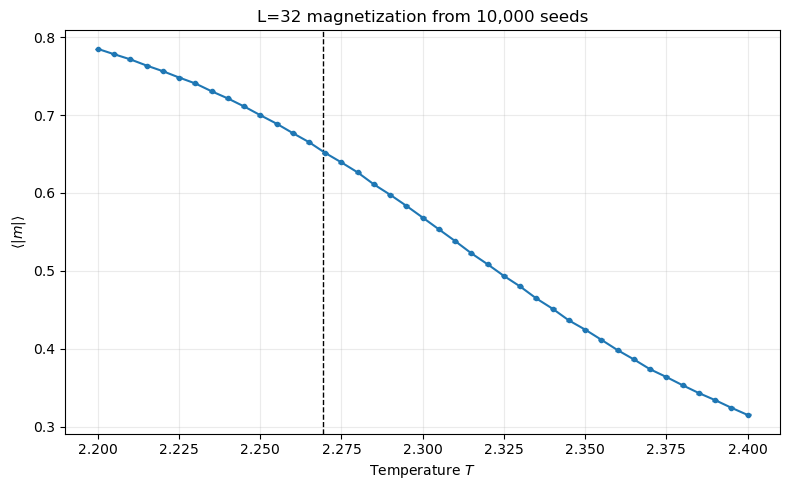

In [2]:
MEAN_SPINS_PATH = OUTPUT_ROOT / "seed_temperature_mean_spins.npy"
MAG_PATH = OUTPUT_ROOT / "seed_temperature_signed_magnetization.npy"

if not MEAN_SPINS_PATH.exists():
    mean_spins = np.lib.format.open_memmap(
        MEAN_SPINS_PATH, mode="w+", dtype=np.float16,
        shape=(N_RUNS, N_TEMPERATURES, L, L),
    )
    magnetization = np.lib.format.open_memmap(
        MAG_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS, N_TEMPERATURES),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        mean_spins[run_index] = spins.mean(axis=1)
        magnetization[run_index] = spins.mean(axis=(1, 2, 3), dtype=np.float64)
        if (run_index + 1) % 500 == 0:
            print(f"Reduced {run_index + 1:,}/{N_RUNS:,} runs")
    mean_spins.flush(); magnetization.flush()

mean_spins = np.load(MEAN_SPINS_PATH, mmap_mode="r")
magnetization = np.load(MAG_PATH, mmap_mode="r")
assert mean_spins.shape == (N_RUNS, N_TEMPERATURES, L, L)

ABS_MAG_PATH = OUTPUT_ROOT / "seed_temperature_absolute_magnetization.npy"
if not ABS_MAG_PATH.exists():
    absolute_magnetization = np.lib.format.open_memmap(
        ABS_MAG_PATH, mode="w+", dtype=np.float32,
        shape=(N_RUNS, N_TEMPERATURES),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        configuration_m = spins.sum(axis=(2, 3), dtype=np.int32) / (L * L)
        absolute_magnetization[run_index] = np.abs(configuration_m).mean(axis=1)
        if (run_index + 1) % 500 == 0:
            print(f"Recomputed |m| for {run_index + 1:,}/{N_RUNS:,} runs")
    absolute_magnetization.flush()

absolute_magnetization = np.load(ABS_MAG_PATH, mmap_mode="r")
mean_abs_m = absolute_magnetization.mean(axis=0)
sem_abs_m = absolute_magnetization.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
assert np.all((mean_abs_m >= 0) & (mean_abs_m <= 1))
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(TEMPERATURES, mean_abs_m, yerr=sem_abs_m, marker="o", ms=3, capsize=2)
ax.axvline(TC, color="black", ls="--", lw=1)
ax.set(xlabel="Temperature $T$", ylabel=r"$\langle |m|\rangle$", title="L=32 magnetization from 10,000 seeds")
ax.grid(alpha=.25); fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "ising32_magnetization_zoom.png", dpi=250)
plt.show()

SAMPLE_BIN = 0
SAMPLE_SPINS_PATH = OUTPUT_ROOT / f"seed_temperature_sample_bin_{SAMPLE_BIN + 1}_spins.npy"
if not SAMPLE_SPINS_PATH.exists():
    sample_cache = np.lib.format.open_memmap(
        SAMPLE_SPINS_PATH, mode="w+", dtype=np.int8,
        shape=(N_RUNS, N_TEMPERATURES, L, L),
    )
    for run_index, run_dir in enumerate(runs):
        name = run_dir.name
        spins = np.loadtxt(run_dir / f"spinConfigs_{name}.txt", dtype=np.int8)
        spins = spins.reshape(N_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
        sample_cache[run_index] = spins[:, SAMPLE_BIN]
        if (run_index + 1) % 500 == 0:
            print(f"Cached matched samples for {run_index + 1:,}/{N_RUNS:,} runs")
    sample_cache.flush()

sample_spins = np.load(SAMPLE_SPINS_PATH, mmap_mode="r")
sample_magnetization = sample_spins.mean(axis=(2, 3), dtype=np.float64).reshape(-1)

In [3]:
def exact_pca(features, cache_name, batch_size=4096):
    cache = OUTPUT_ROOT / cache_name
    if cache.exists():
        data = np.load(cache)
        return data["mean"], data["eigenvalues"], data["components"]
    dimension = features.shape[1]
    total = torch.zeros(dimension, dtype=torch.float64, device=DEVICE)
    second = torch.zeros((dimension, dimension), dtype=torch.float64, device=DEVICE)
    for start in range(0, len(features), batch_size):
        batch = torch.from_numpy(np.asarray(features[start:start + batch_size], dtype=np.float32)).to(DEVICE, dtype=torch.float64)
        total += batch.sum(0); second += batch.T @ batch
    mean_t = total / len(features)
    covariance = (second - len(features) * torch.outer(mean_t, mean_t)) / (len(features) - 1)
    values, vectors = torch.linalg.eigh(covariance)
    order = torch.argsort(values, descending=True)
    mean = mean_t.cpu().numpy(); eigenvalues = values[order].cpu().numpy(); components = vectors[:, order].T.cpu().numpy()
    np.savez(cache, mean=mean, eigenvalues=eigenvalues, components=components)
    return mean, eigenvalues, components

def score_memmap(features, mean, components, path, batch_size=8192):
    if path.exists(): return np.load(path, mmap_mode="r")
    scores = np.lib.format.open_memmap(path, mode="w+", dtype=np.float32, shape=(len(features), len(components)))
    for start in range(0, len(features), batch_size):
        stop = min(start + batch_size, len(features))
        scores[start:stop] = (np.asarray(features[start:stop], np.float32) - mean) @ components.T
    scores.flush(); return np.load(path, mmap_mode="r")

def variance_plot(eigenvalues, prefix):
    evr = eigenvalues / eigenvalues.sum(); cumulative = np.cumsum(evr)
    n90 = int(np.searchsorted(cumulative, .90) + 1)
    x = np.arange(1, n90 + 1)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, evr[:n90], alpha=.8); ax.set(xlabel="PC", ylabel="Explained variance ratio", title=f"{prefix}: {n90} PCs retain 90%")
    other = ax.twinx(); other.plot(x, cumulative[:n90], "o-", color="tab:red", ms=3); other.axhline(.9, color="black", ls="--"); other.set_ylabel("Cumulative variance")
    fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_variance.png", dpi=250); plt.show()
    return evr, cumulative, n90

def pc_visuals(scores, prefix):
    grids = sample_spins.reshape(-1, L, L)
    tail = max(1, int(.02 * len(scores)))

    raw_fig, raw_axes = plt.subplots(5, 3, figsize=(8, 13), constrained_layout=True)
    centered_fig, centered_axes = plt.subplots(5, 3, figsize=(8, 13), constrained_layout=True)

    column_titles = ("Lowest 2% of PC scores", "Highest 2% of PC scores", "High − low")
    for column, title in enumerate(column_titles):
        raw_axes[0, column].set_title(title)
        centered_axes[0, column].set_title(title)

    for pc in range(5):
        values = np.asarray(scores[:, pc])
        order = np.argsort(values)
        low_indices = order[:tail]
        high_indices = order[-tail:]
        low_grids = np.asarray(grids[low_indices], dtype=np.float32)
        high_grids = np.asarray(grids[high_indices], dtype=np.float32)

        low_map = low_grids.mean(axis=0)
        high_map = high_grids.mean(axis=0)
        raw_maps = (low_map, high_map, high_map - low_map)
        raw_limit = max(float(np.max(np.abs(raw_maps))), 1e-3)

        low_centered = (
            low_grids - low_grids.mean(axis=(1, 2), keepdims=True)
        ).mean(axis=0)
        high_centered = (
            high_grids - high_grids.mean(axis=(1, 2), keepdims=True)
        ).mean(axis=0)
        centered_maps = (
            low_centered,
            high_centered,
            high_centered - low_centered,
        )
        centered_limit = max(float(np.max(np.abs(centered_maps))), 1e-4)

        for column, image_data in enumerate(raw_maps):
            raw_axes[pc, column].imshow(
                image_data, cmap="RdBu_r", vmin=-raw_limit, vmax=raw_limit,
                interpolation="nearest",
            )
            raw_axes[pc, column].set_xticks([])
            raw_axes[pc, column].set_yticks([])

        for column, image_data in enumerate(centered_maps):
            centered_axes[pc, column].imshow(
                image_data, cmap="RdBu_r",
                vmin=-centered_limit, vmax=centered_limit,
                interpolation="nearest",
            )
            centered_axes[pc, column].set_xticks([])
            centered_axes[pc, column].set_yticks([])

        raw_axes[pc, 0].set_ylabel(f"PC{pc + 1}", fontsize=12)
        centered_axes[pc, 0].set_ylabel(f"PC{pc + 1}", fontsize=12)

    raw_fig.suptitle(f"{prefix}: spin configurations in the PC-score tails", fontsize=15)
    raw_fig.savefig(
        OUTPUT_ROOT / f"{prefix}_pc_tail_maps.png", dpi=250, bbox_inches="tight"
    )
    plt.show(); plt.close(raw_fig)

    centered_fig.suptitle(
        f"{prefix}: PC-tail patterns after subtracting each configuration's magnetization",
        fontsize=14,
    )
    centered_fig.savefig(
        OUTPUT_ROOT / f"{prefix}_pc_tail_mean_subtracted.png",
        dpi=250, bbox_inches="tight",
    )
    plt.show(); plt.close(centered_fig)

def cluster_analysis(features, scores90, prefix):
    models = {"PCA 90%": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20), "Full": MiniBatchKMeans(3, random_state=42, batch_size=4096, n_init=20)}
    labels = {"PCA 90%": models["PCA 90%"].fit_predict(scores90), "Full": models["Full"].fit_predict(features)}
    flat_m = sample_magnetization
    flat_t = np.tile(TEMPERATURES, N_RUNS)
    rows=[]
    for method, lab in labels.items():
        order=np.argsort([flat_m[lab==c].mean() for c in range(3)]); remap=np.empty(3,int); remap[order]=np.arange(3); lab=remap[lab]; labels[method]=lab
        for ti,t in enumerate(TEMPERATURES):
            at=lab[flat_t==t]
            for c in range(3): rows.append({"method":method,"temperature":t,"cluster":c,"fraction":float(np.mean(at==c))})
    table=pd.DataFrame(rows); table.to_csv(OUTPUT_ROOT / f"{prefix}_cluster_populations.csv",index=False)
    fig,axes=plt.subplots(1,2,figsize=(14,5),sharex=True,sharey=True)
    for ax,method in zip(axes,labels):
        for c in range(3):
            d=table[(table.method==method)&(table.cluster==c)]; ax.plot(d.temperature,d.fraction,"o-",ms=3,label=f"Cluster {c}")
        ax.axvline(TC,color="black",ls="--"); ax.set(title=method,xlabel="T",ylim=(-.02,1.02)); ax.grid(alpha=.25); ax.legend()
    axes[0].set_ylabel("Cluster fraction"); fig.suptitle(f"{prefix} unsupervised clusters"); fig.tight_layout(); fig.savefig(OUTPUT_ROOT / f"{prefix}_cluster_populations.png",dpi=250); plt.show()
    np.savez(OUTPUT_ROOT / f"{prefix}_cluster_labels.npz",pca90=labels["PCA 90%"],full=labels["Full"])
    return labels

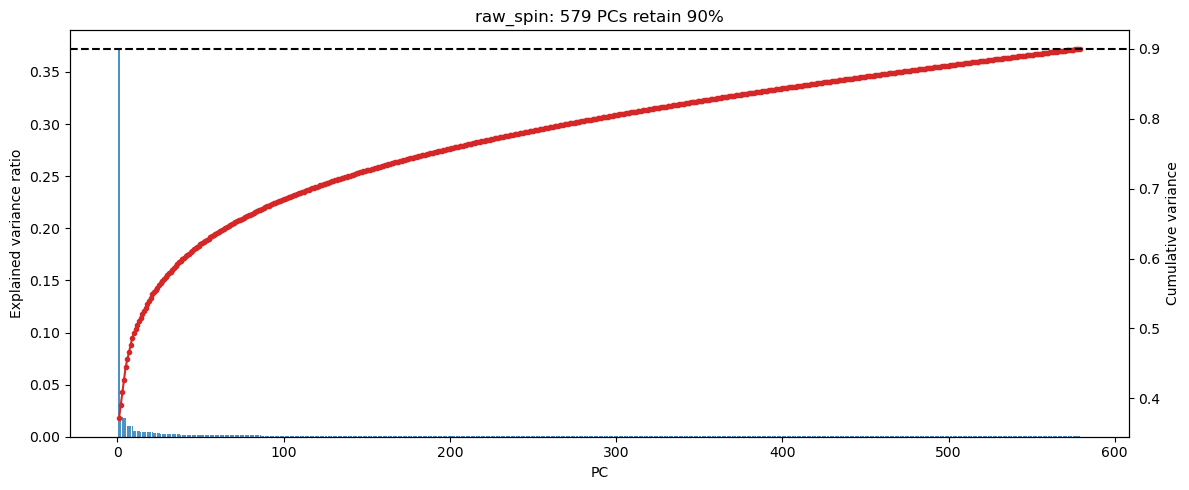

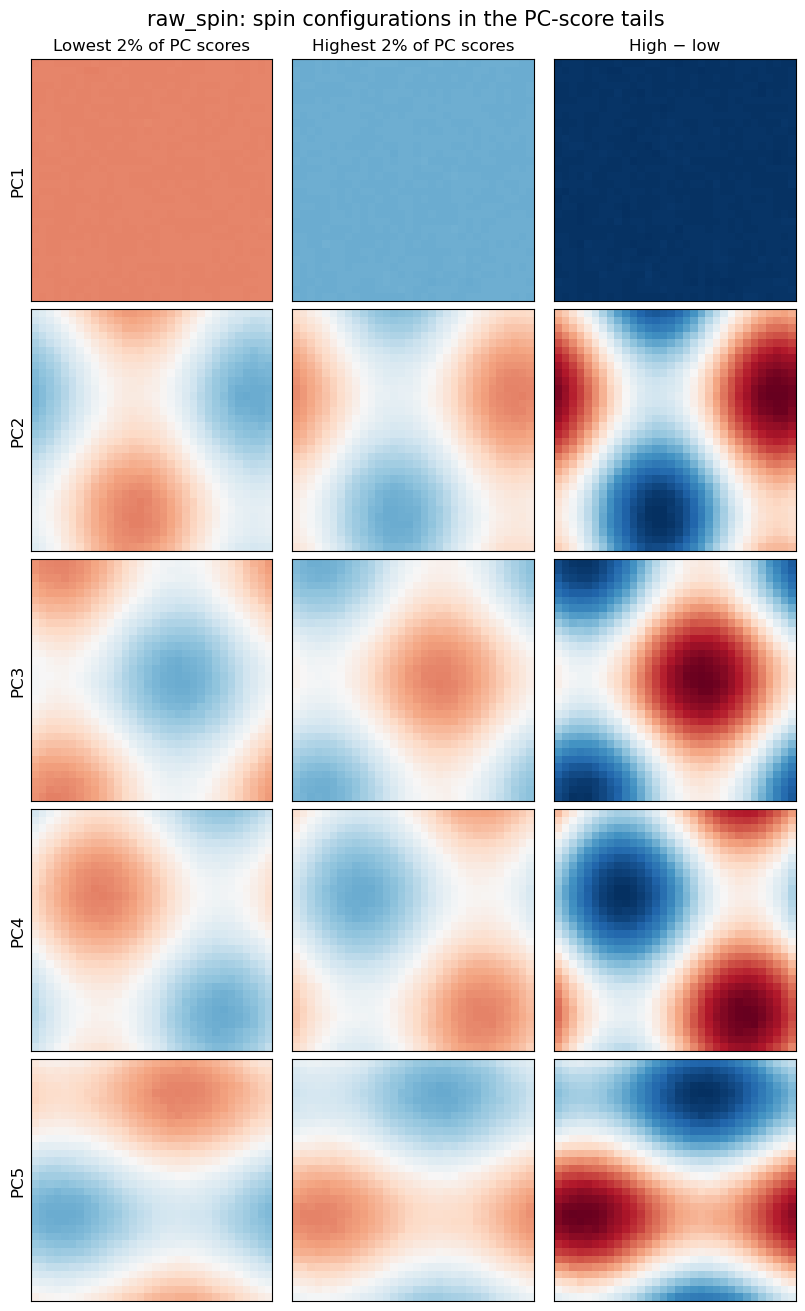

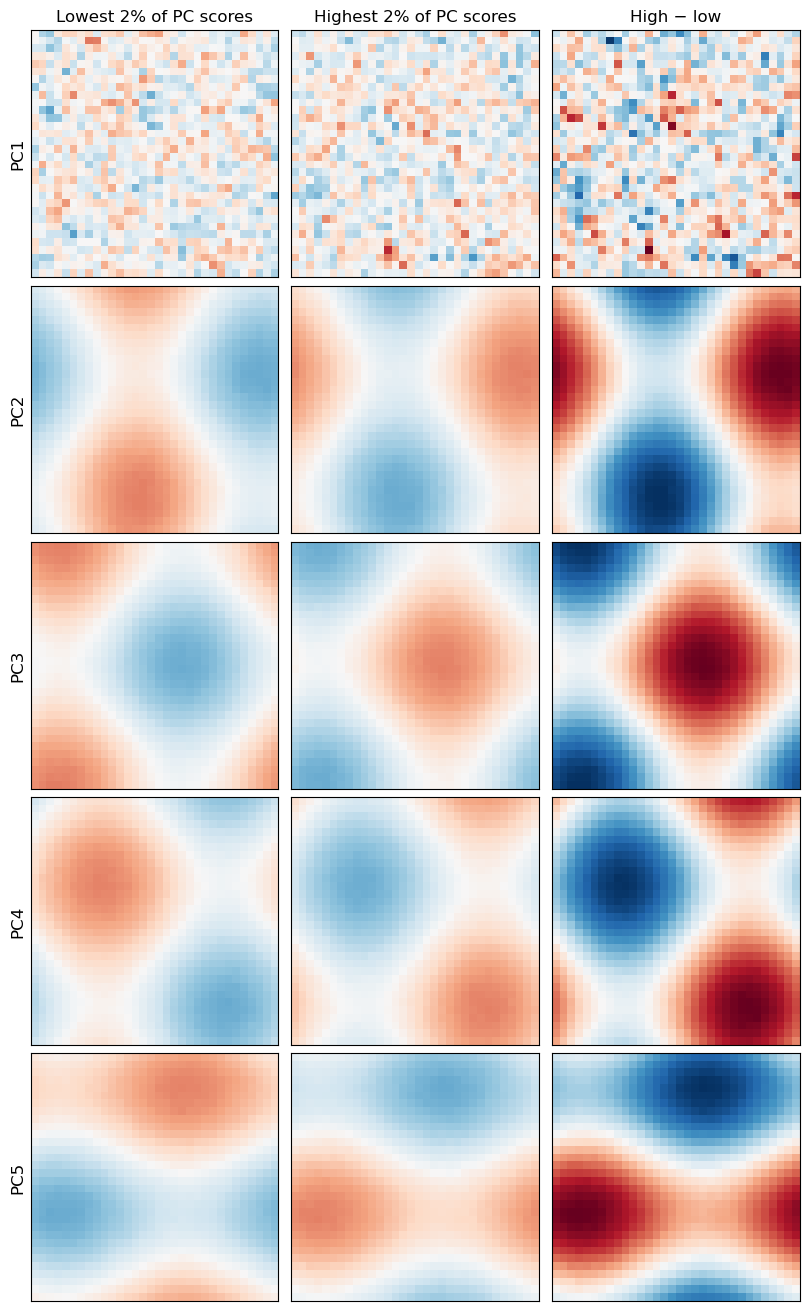

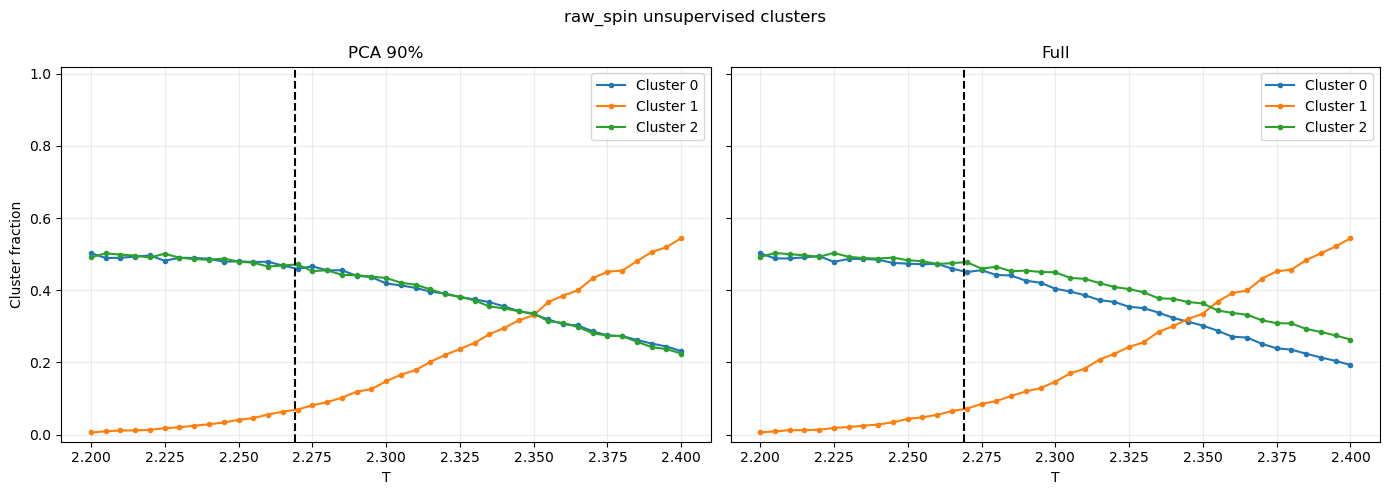

In [4]:
raw_features=sample_spins.reshape(-1,L*L)
raw_mean,raw_eigenvalues,raw_components=exact_pca(raw_features,"raw_sample_pca.npz",batch_size=2048)
raw_evr,raw_cumulative,raw_n90=variance_plot(raw_eigenvalues,"raw_spin")
raw_scores=score_memmap(raw_features,raw_mean,raw_components[:raw_n90],OUTPUT_ROOT/"raw_sample_pca90_scores.npy",batch_size=4096)
pc_visuals(raw_scores,"raw_spin")
raw_labels=cluster_analysis(raw_features,raw_scores,"raw_spin")
with open(OUTPUT_ROOT/"raw_spin_summary.json","w") as f: json.dump({"n_components_90":raw_n90,"variance_first5":raw_evr[:5].tolist()},f,indent=2)

## Direct comparison with frozen ResNet

In [5]:
with open(OUTPUT_ROOT/"resnet18_summary.json") as f: resnet_summary=json.load(f)
resnet_cluster=np.load(OUTPUT_ROOT/"resnet18_cluster_labels.npz")
raw_cluster=np.load(OUTPUT_ROOT/"raw_spin_cluster_labels.npz")
rng=np.random.default_rng(42); sample=rng.choice(len(raw_features),size=50000,replace=False)
comparison=pd.DataFrame([
    {"representation":"Frozen ResNet-18","PCs_for_90pct":resnet_summary["n_components_90"],"AMI_PCA90_vs_full":adjusted_mutual_info_score(resnet_cluster["pca90"],resnet_cluster["full"])},
    {"representation":"Raw spin field","PCs_for_90pct":raw_n90,"AMI_PCA90_vs_full":adjusted_mutual_info_score(raw_cluster["pca90"],raw_cluster["full"])},
])
cross_ami=adjusted_mutual_info_score(resnet_cluster["pca90"],raw_cluster["pca90"])
comparison["ResNet_raw_PCA90_AMI"]=cross_ami
comparison.to_csv(OUTPUT_ROOT/"resnet_vs_raw_pca_comparison.csv",index=False)
comparison

,representation,PCs_for_90pct,AMI_PCA90_vs_full,ResNet_raw_PCA90_AMI
0,Frozen ResNet-18,32,0.718285,0.711175
1,Raw spin field,579,0.874938,0.711175


In [6]:
rng = np.random.default_rng(42)
silhouette_indices = np.sort(rng.choice(len(raw_features), size=10_000, replace=False))
resnet_scores = np.load(OUTPUT_ROOT / "resnet18_sample_pca90_scores.npy", mmap_mode="r")
resnet_silhouette = silhouette_score(
    np.asarray(resnet_scores[silhouette_indices]),
    resnet_cluster["pca90"][silhouette_indices],
)
raw_silhouette = silhouette_score(
    np.asarray(raw_scores[silhouette_indices]),
    raw_cluster["pca90"][silhouette_indices],
)

quality = pd.DataFrame([
    {"representation": "Frozen ResNet-18", "silhouette_PCA90": resnet_silhouette},
    {"representation": "Raw spin field", "silhouette_PCA90": raw_silhouette},
])
quality.to_csv(OUTPUT_ROOT / "resnet_vs_raw_pca_cluster_quality.csv", index=False)
quality

,representation,silhouette_PCA90
0,Frozen ResNet-18,0.282172
1,Raw spin field,0.210868


## Interpretation

The earlier raw-PCA comparison contained a preprocessing mismatch: it averaged the ten saved spin configurations before PCA, while ResNet embeddings were computed first and averaged afterward. Because a finite Ising sample can flip its global sign between saved configurations, averaging spins first partially cancelled the signed magnetization that raw PC1 should capture.

The corrected comparison feeds the **same actual saved configuration** to both representations for every seed-temperature pair. Raw PC1 now contains the expected signed-magnetization direction. Using only raw PCs 1–5 gives a silhouette score of **0.479**, compared with **0.211** when K-means is given all 579 PCs needed for 90% raw-spin variance. The extra PCs mostly describe microscopic fluctuations and dilute Euclidean distances; retaining 90% variance is therefore not an appropriate clustering rule here.

The five-PC clusters have mean signed magnetizations **-0.652**, **0.022**, and **+0.664**. Thus K-means finds the two symmetry-related ordered sectors plus a low-magnetization/disordered sector without using temperature labels. At T=2.200 only **0.54%** of samples occupy the low-magnetization cluster; by T=2.400 that fraction is **54.46%**. The crossover is broad because this finite-size temperature window straddles the transition and cluster membership is not itself a sharp phase estimator.

For the matched 90%-variance comparison, frozen ResNet requires 32 PCs and scores 0.282, while raw spins require 579 PCs and score 0.211. ResNet compresses variance more efficiently, but the physically selected five-dimensional raw representation clusters better than either 90%-variance representation. This means the earlier weak raw-PCA result was a preprocessing and component-selection artifact, not evidence that ResNet had discovered a superior phase coordinate.

## Five-PC clustering

K-means is fitted using only raw PCs 1–5. PC1 is the signed-magnetization direction; PCs 2–5 retain the strongest spatial fluctuation modes without swamping distances with hundreds of low-variance microscopic directions. Cluster labels are reordered afterward by mean signed magnetization for a stable display; temperature is not used during fitting.

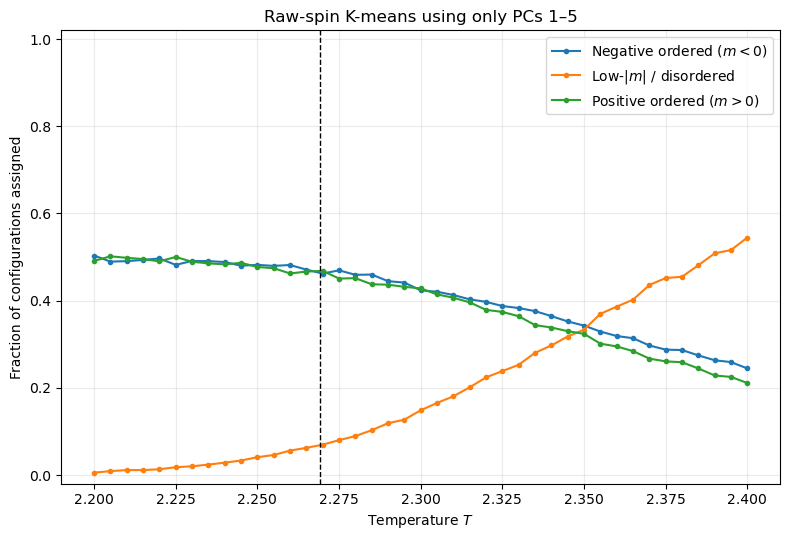

Five-PC silhouette score: 0.4787


,cluster,mean_signed_magnetization,mean_absolute_magnetization,population
0,0,-0.652082,0.652082,0.407166
1,1,0.022243,0.171546,0.198907
2,2,0.663505,0.663505,0.393927


In [7]:
PCA5_COMPONENTS = 5
pca5_features = raw_scores[:, :PCA5_COMPONENTS]
pca5_model = MiniBatchKMeans(
    n_clusters=3,
    random_state=42,
    batch_size=4096,
    n_init=20,
)
pca5_labels_unordered = pca5_model.fit_predict(pca5_features)

flat_m = sample_magnetization
flat_t = np.tile(TEMPERATURES, N_RUNS)
cluster_order = np.argsort([
    flat_m[pca5_labels_unordered == cluster].mean()
    for cluster in range(3)
])
label_map = np.empty(3, dtype=int)
label_map[cluster_order] = np.arange(3)
pca5_labels = label_map[pca5_labels_unordered]

pca5_rows = []
for temperature in TEMPERATURES:
    labels_at_temperature = pca5_labels[flat_t == temperature]
    for cluster in range(3):
        pca5_rows.append({
            "temperature": temperature,
            "cluster": cluster,
            "fraction": float(np.mean(labels_at_temperature == cluster)),
        })
pca5_populations = pd.DataFrame(pca5_rows)
pca5_populations.to_csv(
    OUTPUT_ROOT / "raw_spin_pca5_cluster_populations.csv", index=False
)
np.save(OUTPUT_ROOT / "raw_spin_pca5_cluster_labels.npy", pca5_labels)

cluster_names = {0: "Negative ordered ($m < 0$)", 1: "Low-$|m|$ / disordered", 2: "Positive ordered ($m > 0$)"}

fig, ax = plt.subplots(figsize=(8, 5.5))
for cluster in range(3):
    data = pca5_populations[pca5_populations.cluster == cluster]
    ax.plot(
        data.temperature, data.fraction,
        "o-", markersize=3, label=cluster_names[cluster],
    )
ax.axvline(TC, color="black", linestyle="--", linewidth=1)
ax.set(
    xlabel="Temperature $T$",
    ylabel="Fraction of configurations assigned",
    title="Raw-spin K-means using only PCs 1–5",
    ylim=(-0.02, 1.02),
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(
    OUTPUT_ROOT / "raw_spin_pca5_cluster_populations.png",
    dpi=250,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)

rng = np.random.default_rng(43)
pca5_sample = np.sort(rng.choice(len(pca5_features), size=10_000, replace=False))
pca5_silhouette = silhouette_score(
    np.asarray(pca5_features[pca5_sample]),
    pca5_labels[pca5_sample],
)

pca5_cluster_summary = pd.DataFrame({
    "cluster": np.arange(3),
    "mean_signed_magnetization": [
        flat_m[pca5_labels == cluster].mean() for cluster in range(3)
    ],
    "mean_absolute_magnetization": [
        np.abs(flat_m[pca5_labels == cluster]).mean() for cluster in range(3)
    ],
    "population": [np.mean(pca5_labels == cluster) for cluster in range(3)],
})
pca5_cluster_summary.to_csv(
    OUTPUT_ROOT / "raw_spin_pca5_cluster_summary.csv", index=False
)
print(f"Five-PC silhouette score: {pca5_silhouette:.4f}")
pca5_cluster_summary